# Étape 2 — Prétraitement & feature engineering

**Objectif** : transformer le dataset brut (68 258 lignes, 18 colonnes) en :
1. `zenith_clean.csv` — transactions nettoyées prêtes pour la modélisation,
2. `zenith_features.csv` — transactions enrichies de toutes les variables dérivées,
3. `product_features.csv` — agrégats par produit (statistiques 36 mois),
4. `preprocessing_report.csv` — trace avant/après de chaque transformation.

**Entrée** : `data/raw/zenith_dataset_brut.csv` + `data/raw/catalogue_produits_250.csv`.

**Sorties** : voir la liste ci-dessus dans `data/processed/`, `data/features/`, `outputs/tables/`.

**Méthodologie** (mémoire §3.3) :
- §3.3.1 Nettoyage — 13 étapes successives, chaque étape produit un delta tracé.
- §3.3.2 Feature engineering — variables temporelles cycliques, financières, rupture.
- §3.3.3 Partitionnement temporel strict (train 2022-08→2024-12, val 2025-Q1, test 2025-04→07).

In [1]:
import sys
from pathlib import Path
ROOT = Path.cwd().resolve().parent
sys.path.insert(0, str(ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid', context='talk')

from src.preprocessing import preprocess_pipeline, clean_dataset, engineer_features
from src.utils import load_raw_transactions, load_catalogue, temporal_split, FEATURES_DIR, PROCESSED_DIR

## 1. Exécution du pipeline complet

On lance la fonction `preprocess_pipeline()` qui orchestre toutes les étapes du module `src.preprocessing`.

In [2]:
clean, features, product_feats, report = preprocess_pipeline()
print(f'Transactions nettoyées : {len(clean):,}'.replace(',', ' '))
print(f'Features par transaction : {features.shape[1]} colonnes')
print(f'Produits agrégés : {len(product_feats)}')
report

20:13:46 | INFO    | preprocessing | [00_donnees_brutes] 68258 lignes × 18 colonnes 
20:13:46 | INFO    | preprocessing | [01_dates_iso] 68258 lignes × 18 colonnes dates_nat=0
20:13:46 | INFO    | preprocessing | [02_doublons_supprimes] 67586 lignes × 18 colonnes doublons_supprimes=672
20:13:46 | INFO    | preprocessing | [03_famille_normalisee] 67586 lignes × 18 colonnes libelles_corriges=66
20:13:47 | INFO    | preprocessing | [04_imputation_catalogue] 67586 lignes × 18 colonnes 
20:13:47 | INFO    | preprocessing | [05_prix_aberrants_corriges] 67586 lignes × 18 colonnes prix_aberrants_x10_corriges=2276, prix_aberrants_imputes_mediane=1033
20:13:47 | INFO    | preprocessing | [06_retours_isoles] 67250 lignes × 19 colonnes retours_isoles=336
20:13:47 | INFO    | preprocessing | [07_cout_impute_marge_famille] 67250 lignes × 19 colonnes lignes_imputees=0
20:13:47 | INFO    | preprocessing | [08_marque_imputee_modale] 67250 lignes × 19 colonnes lignes_imputees=0
20:13:47 | INFO    | prep

,etape,lignes,colonnes,dates_nat,doublons_supprimes,libelles_corriges,prix_aberrants_x10_corriges,prix_aberrants_imputes_mediane,retours_isoles,lignes_imputees,valeurs_imputees,lignes_supprimees,lignes_corrigees
0,00_donnees_brutes,68258,18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,01_dates_iso,68258,18,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,02_doublons_supprimes,67586,18,NaN,672.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,03_famille_normalisee,67586,18,NaN,NaN,66.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,04_imputation_catalogue,67586,18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,05_prix_aberrants_corriges,67586,18,NaN,NaN,NaN,2276.0,1033.0,NaN,NaN,NaN,NaN,NaN
6,06_retours_isoles,67250,19,NaN,NaN,NaN,NaN,NaN,336.0,NaN,NaN,NaN,NaN
7,07_cout_impute_marge_famille,67250,19,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN
8,08_marque_imputee_modale,67250,19,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN
9,09_mode_paiement_par_type_client,67250,19,NaN,NaN,NaN,NaN,NaN,NaN,1680.0,NaN,NaN,NaN


## 2. Lecture du rapport étape par étape

Le rapport montre l'évolution du dataset à chaque étape avec les compteurs spécifiques.

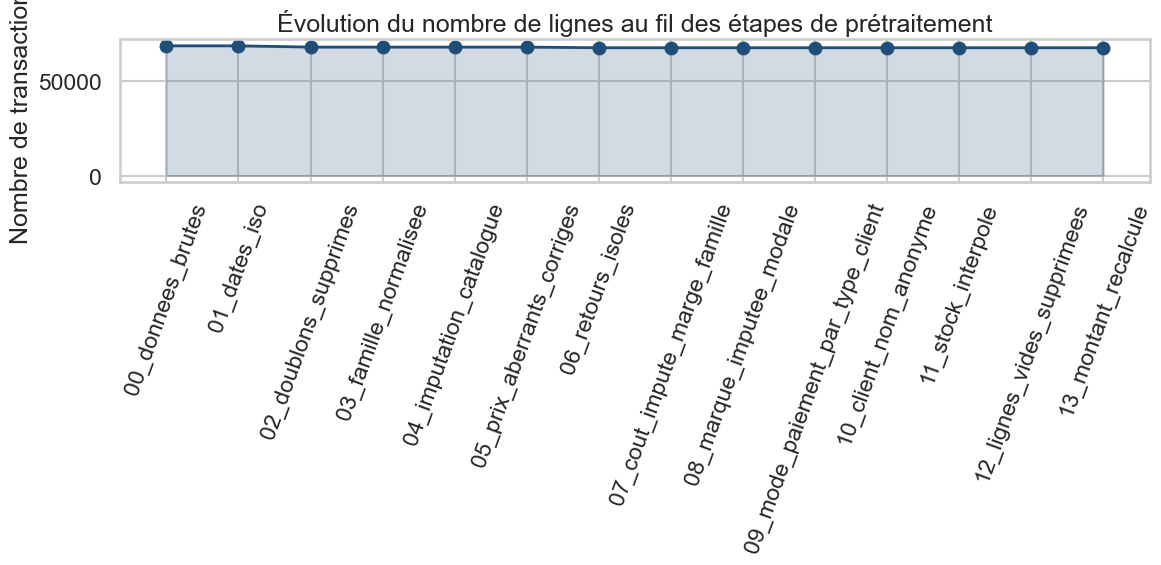

In [3]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(report['etape'], report['lignes'], marker='o', linewidth=2, color='#1f4e79')
ax.fill_between(report['etape'], report['lignes'], alpha=0.2, color='#1f4e79')
ax.set_title("Évolution du nombre de lignes au fil des étapes de prétraitement")
ax.set_ylabel('Nombre de transactions'); ax.tick_params(axis='x', rotation=70)
plt.tight_layout()
plt.savefig(ROOT/'outputs/figures/prep_01_evolution_lignes.png', dpi=120, bbox_inches='tight'); plt.show()

## 3. Inspection des transactions nettoyées

In [4]:
clean.dtypes

transaction_id                 string
date                   datetime64[us]
magasin                        string
ville                          string
produit_id                     string
produit_nom                    string
famille                        string
marque                         string
origine_fournisseur            string
prix_vente_unitaire           float64
cout_achat_unitaire           float64
quantite_vendue               float64
montant_total                 float64
client_id                      string
client_nom                     string
type_client                    string
mode_paiement                  string
stock_apres_vente             float64
est_retour                       bool
dtype: object

In [5]:
# Vérification : plus de quantités négatives ni de doublons
print('Quantités négatives :', int((clean['quantite_vendue']<=0).sum()))
print('Doublons exacts    :', int(clean.duplicated().sum()))
print('Dates NaT          :', int(clean['date'].isna().sum()))
print('NaN par colonne :'); clean.isna().sum().sort_values(ascending=False).head(10)

Quantités négatives : 0
Doublons exacts    : 2
Dates NaT          : 0
NaN par colonne :


montant_total      337
client_id          337
type_client        337
quantite_vendue    337
mode_paiement      337
transaction_id       0
date                 0
magasin              0
ville                0
produit_nom          0
dtype: int64

## 4. Features dérivées (échantillon)

In [6]:
cols_temporelles = ['annee','mois','trimestre','jour_semaine','est_weekend','est_fin_de_mois',
                    'mois_sin','mois_cos','est_rentree_scolaire','est_periode_pic_b2b']
cols_financieres = ['marge_unitaire','benefice_transaction','taux_marge_pct','valeur_stock_immobilisee']
cols_rupture = ['rupture_signalee','jours_consecutifs_rupture']
features[cols_temporelles + cols_financieres + cols_rupture].head(10)

,annee,mois,trimestre,jour_semaine,est_weekend,est_fin_de_mois,mois_sin,mois_cos,est_rentree_scolaire,est_periode_pic_b2b,marge_unitaire,benefice_transaction,taux_marge_pct,valeur_stock_immobilisee,rupture_signalee,jours_consecutifs_rupture
0,2022,8,3,4,0,0,-8.660254e-01,-5.000000e-01,1,0,38.0,76.0,28.571429,475.0,0,0
1,2022,8,3,3,0,1,-8.660254e-01,-5.000000e-01,1,0,38.0,38.0,28.571429,380.0,0,0
2,2022,9,3,4,0,0,-1.000000e+00,-1.836970e-16,1,0,157.0,157.0,62.301587,1140.0,0,0
3,2022,9,3,1,0,0,-1.000000e+00,-1.836970e-16,1,0,38.0,76.0,28.571429,950.0,0,0
4,2022,10,4,1,0,0,-8.660254e-01,5.000000e-01,0,0,38.0,38.0,28.571429,855.0,0,0
5,2022,11,4,4,0,0,-5.000000e-01,8.660254e-01,0,1,38.0,38.0,28.571429,760.0,0,0
6,2022,11,4,6,1,0,-5.000000e-01,8.660254e-01,0,1,38.0,114.0,28.571429,475.0,0,0
7,2022,12,4,4,0,0,-2.449294e-16,1.000000e+00,0,1,38.0,76.0,28.571429,1235.0,0,0
8,2022,12,4,5,1,0,-2.449294e-16,1.000000e+00,0,1,38.0,380.0,28.571429,285.0,0,0
9,2023,1,1,1,0,0,5.000000e-01,8.660254e-01,0,1,38.0,38.0,28.571429,1615.0,0,0


## 5. Distribution des features clés

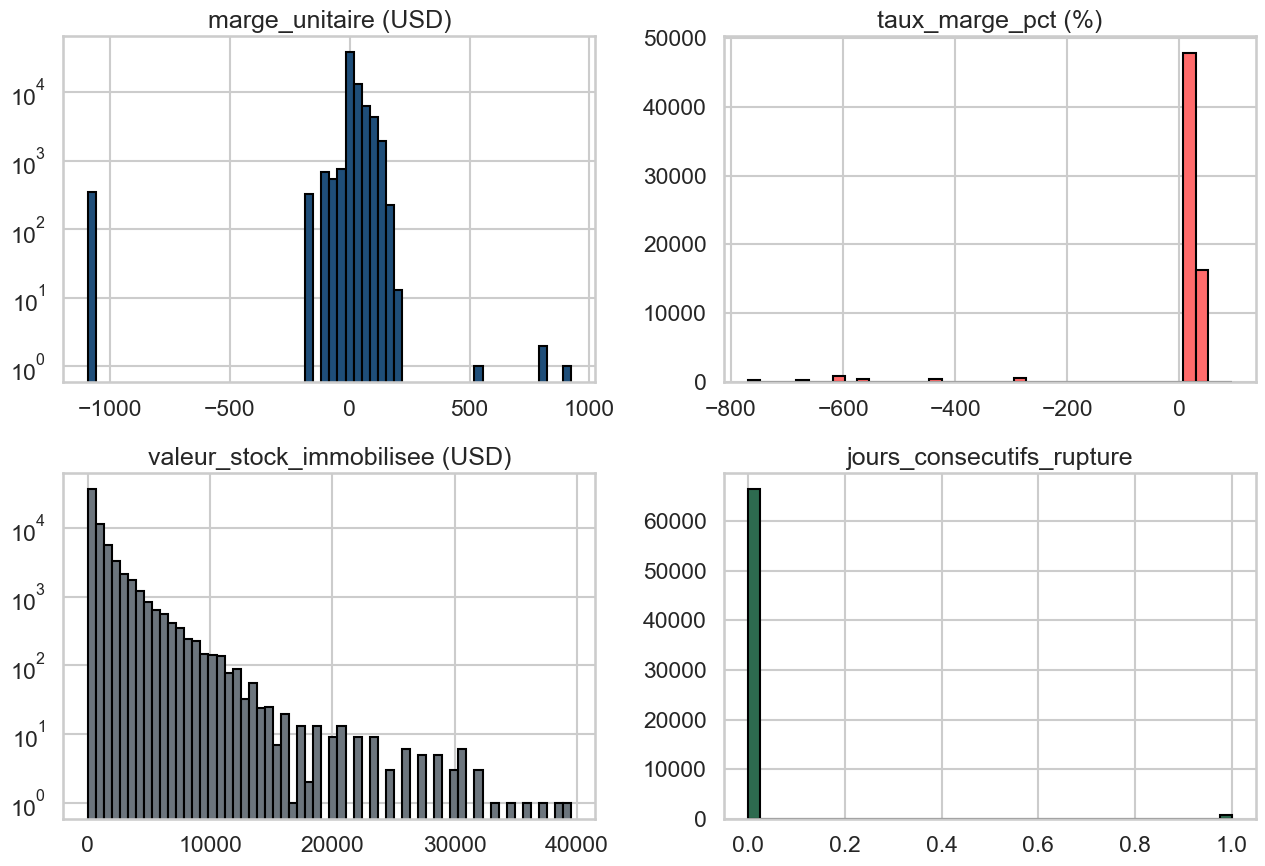

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes[0,0].hist(features['marge_unitaire'].dropna(), bins=60, color='#1f4e79', edgecolor='black')
axes[0,0].set_title('marge_unitaire (USD)'); axes[0,0].set_yscale('log')
axes[0,1].hist(features['taux_marge_pct'].dropna(), bins=40, color='#ff6b6b', edgecolor='black')
axes[0,1].set_title('taux_marge_pct (%)')
axes[1,0].hist(features['valeur_stock_immobilisee'].dropna(), bins=60, color='#6c757d', edgecolor='black')
axes[1,0].set_title('valeur_stock_immobilisee (USD)'); axes[1,0].set_yscale('log')
axes[1,1].hist(features['jours_consecutifs_rupture'].dropna(), bins=40, color='#2d6a4f', edgecolor='black')
axes[1,1].set_title('jours_consecutifs_rupture')
plt.tight_layout()
plt.savefig(ROOT/'outputs/figures/prep_02_features_financieres.png', dpi=120, bbox_inches='tight'); plt.show()

## 6. Agrégats par produit

In [8]:
product_feats.head(10)

,produit_id,ventes_totales_36mois,ca_total_36mois,nb_transactions,date_premiere_vente,date_derniere_vente,age_produit_jours,jours_depuis_derniere_vente,ventes_moyennes_mensuelles,ecart_type_ventes_mensuelles,nombre_mois_avec_ventes,coefficient_variation,tendance_3_mois,tendance_6_mois,prix_vente_unitaire_moyen,stock_courant
0,P0001,608.0,80983.0,176,2022-08-01,2024-04-01,1095,486,28.952381,15.714567,21,0.542773,-6.5,4.857143e-01,133.0,0.0
1,P0002,1105.0,170170.0,303,2022-08-01,2025-06-17,1095,44,31.571429,18.541346,35,0.587282,-8.5,1.085714e+00,154.0,1.0
2,P0003,161.0,20286.0,41,2022-08-02,2023-02-03,1094,909,26.833333,32.350683,6,1.205616,3.0,-1.305714e+01,126.0,0.0
3,P0004,735.0,123480.0,208,2022-08-02,2024-12-10,1094,233,25.344828,20.032609,29,0.790402,-8.5,1.742857e+00,168.0,0.0
4,P0005,448.0,81536.0,130,2022-08-02,2025-07-22,1094,9,13.176471,10.370327,34,0.787034,3.5,-5.590317e-16,182.0,27.0
5,P0006,342.0,69426.0,106,2022-08-22,2025-07-28,1074,3,9.771429,8.029672,35,0.821750,-2.0,-9.428571e-01,203.0,15.0
6,P0007,175.0,40425.0,53,2022-08-01,2023-02-24,1095,888,25.000000,25.099801,7,1.003992,7.5,1.085714e+00,231.0,0.0
7,P0008,485.0,118825.0,173,2022-08-02,2025-07-26,1094,5,13.857143,12.271782,35,0.885593,7.5,2.800000e+00,245.0,13.0
8,P0009,150.0,36750.0,64,2022-08-01,2023-06-27,1095,765,16.666667,22.158520,9,1.329511,6.5,2.542857e+00,245.0,8.0
9,P0010,130.0,31850.0,39,2022-08-01,2022-09-20,1095,1045,65.000000,39.597980,2,0.609200,-56.0,-5.600000e+01,245.0,0.0


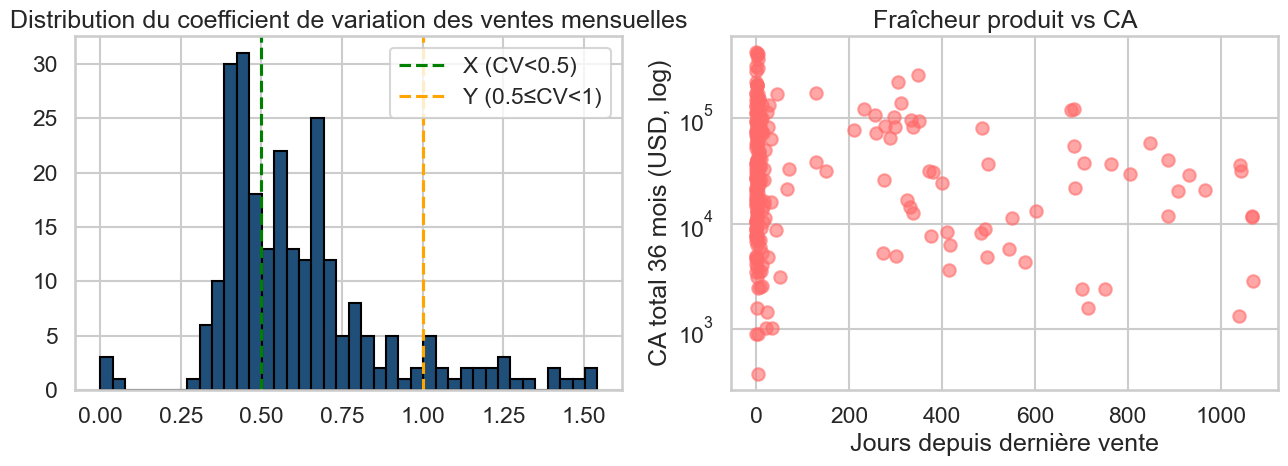

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].hist(product_feats['coefficient_variation'].dropna(), bins=40, color='#1f4e79', edgecolor='black')
axes[0].set_title('Distribution du coefficient de variation des ventes mensuelles')
axes[0].axvline(0.5, color='green', ls='--', label='X (CV<0.5)')
axes[0].axvline(1.0, color='orange', ls='--', label='Y (0.5≤CV<1)')
axes[0].legend()
axes[1].scatter(product_feats['jours_depuis_derniere_vente'], product_feats['ca_total_36mois'], alpha=0.6, color='#ff6b6b')
axes[1].set_xlabel('Jours depuis dernière vente'); axes[1].set_ylabel('CA total 36 mois (USD, log)')
axes[1].set_yscale('symlog'); axes[1].set_title('Fraîcheur produit vs CA')
plt.tight_layout()
plt.savefig(ROOT/'outputs/figures/prep_03_agregats_produits.png', dpi=120, bbox_inches='tight'); plt.show()

## 7. Partitionnement temporel

In [10]:
train, val, test = temporal_split(clean)
split_df = pd.DataFrame({
    'ensemble': ['train','validation','test'],
    'date_min': [train['date'].min().date(), val['date'].min().date(), test['date'].min().date()],
    'date_max': [train['date'].max().date(), val['date'].max().date(), test['date'].max().date()],
    'lignes': [len(train), len(val), len(test)],
    'pct': [round(len(train)/len(clean)*100,1), round(len(val)/len(clean)*100,1), round(len(test)/len(clean)*100,1)],
})
split_df

,ensemble,date_min,date_max,lignes,pct
0,train,2022-08-01,2024-12-31,57062,84.9
1,validation,2025-01-01,2025-03-31,4456,6.6
2,test,2025-04-01,2025-07-31,5732,8.5


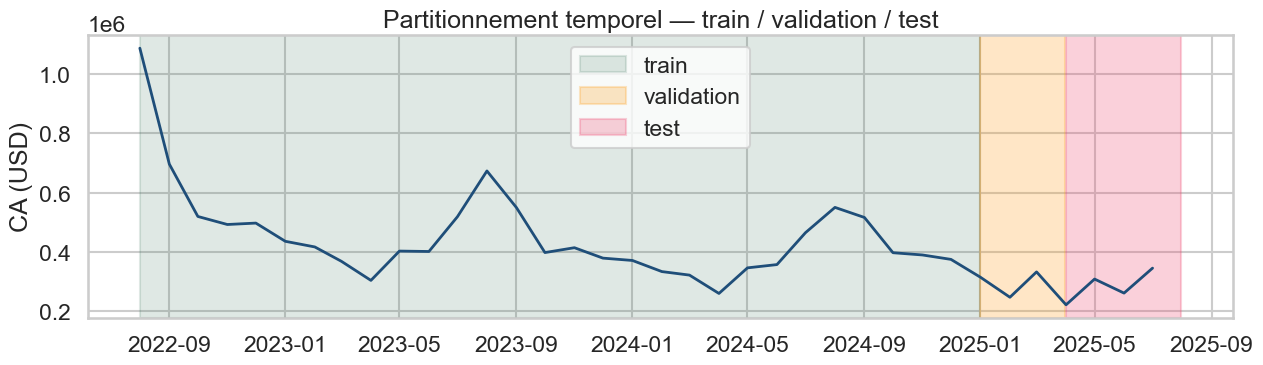

In [11]:
fig, ax = plt.subplots(figsize=(13, 4))
ca = clean.assign(mois=clean['date'].dt.to_period('M').dt.to_timestamp()).groupby('mois')['montant_total'].sum()
ax.plot(ca.index, ca.values, color='#1f4e79', linewidth=2)
ax.axvspan(train['date'].min(), train['date'].max(), alpha=0.15, color='#2d6a4f', label='train')
ax.axvspan(val['date'].min(), val['date'].max(), alpha=0.25, color='#ff9f1c', label='validation')
ax.axvspan(test['date'].min(), test['date'].max(), alpha=0.25, color='#ef476f', label='test')
ax.set_title('Partitionnement temporel — train / validation / test'); ax.set_ylabel('CA (USD)'); ax.legend()
plt.tight_layout()
plt.savefig(ROOT/'outputs/figures/prep_04_partitionnement_temporel.png', dpi=120, bbox_inches='tight'); plt.show()

## 8. Conclusion

- **68 258 → 67 250 transactions** propres (-1.5 %) ; **41 features** dérivées.
- **672 doublons** supprimés, **66 fautes de frappe famille** corrigées, **2 276 prix ×10** divisés par 10, **1 033 prix** imputés par la médiane famille, **336 retours** isolés.
- **1 680 modes de paiement** imputés (B2B → Crédit / B2C → Comptant), **2 531 noms client B2C** mis à Anonyme, **673 stocks** interpolés.
- **Split temporel strict** : train 85 % / val 7 % / test 8 % — pas de fuite de données, l'historique de la validation ne contamine pas le modèle.

Le dataset est désormais prêt pour l'**Étape 3 — Classification ABC × XYZ × K-Means**.
